## 1. Setup

In [1]:
import os, torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NONE')

WORK_DIR = '/kaggle/working'
CKPT_DIR = os.path.join(WORK_DIR, 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)
CKPT_PATH = os.path.join(CKPT_DIR, 'best_model.pt')
print('Checkpoints ->', CKPT_PATH)

Device: cuda
GPU: Tesla T4
Checkpoints -> /kaggle/working/checkpoints/best_model.pt


In [2]:
!pip install -q audiomentations==0.35.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.3/82.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.1/260.1 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 7.5 MB/s eta 0:00:00


## 2. Locate mounted datasets (auto-discovery)

In [3]:
import os

FOR_ROOT = '/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm'
print('FOR_ROOT:', FOR_ROOT, '| splits:', os.listdir(FOR_ROOT))

ASV_ROOT = '/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA'
print('ASV_ROOT:', ASV_ROOT, '| contents:', os.listdir(ASV_ROOT))

PROTO_DIR = os.path.join(ASV_ROOT, 'ASVspoof2019_LA_cm_protocols')
print('PROTO_DIR:', PROTO_DIR, '| contents:', os.listdir(PROTO_DIR))

FOR_ROOT: /kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm | splits: ['validation', 'training', 'testing']
ASV_ROOT: /kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA | contents: ['ASVspoof2019_LA_dev', 'ASVspoof2019_LA_train', 'ASVspoof2019_LA_cm_protocols', 'ASVspoof2019_LA_eval', 'ASVspoof2019_LA_asv_protocols', 'README.LA.txt', 'ASVspoof2019_LA_asv_scores']
PROTO_DIR: /kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_cm_protocols | contents: ['ASVspoof2019.LA.cm.eval.trl.txt', 'ASVspoof2019.LA.cm.train.trn.txt', 'ASVspoof2019.LA.cm.dev.trl.txt']


## 3. Configuration

In [4]:
SR = 16000
DURATION = 3.0
N_SAMPLES = int(SR*DURATION)
N_MELS = 64
N_FFT = 1024
HOP_LENGTH = 256
TARGET_RMS = 0.05
BATCH_SIZE = 64

## 4. Preprocessing (shared by training and inference)

In [5]:
import numpy as np, librosa

def fix_length(y, train=False):
    n = len(y)
    if n < N_SAMPLES:
        reps = int(np.ceil(N_SAMPLES / n))
        y = np.tile(y, reps)[:N_SAMPLES]
    elif n > N_SAMPLES:
        start = np.random.randint(0, n - N_SAMPLES + 1) if train else (n - N_SAMPLES)//2
        y = y[start:start + N_SAMPLES]
    return y

def loudness_normalize(y, target_rms=TARGET_RMS):
    rms = np.sqrt(np.mean(y**2)) + 1e-9
    return y * (target_rms / rms)

def waveform_to_logmel(y):
    mel = librosa.feature.melspectrogram(y=y, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
    lm = librosa.power_to_db(mel, ref=np.max)
    return ((lm - lm.mean()) / (lm.std() + 1e-9)).astype(np.float32)

def preprocess(path_or_array, train=False, sr_in=None):
    if isinstance(path_or_array, str):
        y, _ = librosa.load(path_or_array, sr=SR, mono=True)
    else:
        y = np.asarray(path_or_array, dtype=np.float32)
        if y.ndim > 1: 
            y = y.mean(axis=1)
        if sr_in is not None and sr_in != SR:
            y = librosa.resample(y, orig_sr=sr_in, target_sr=SR)
            
    y = fix_length(y, train=train)
    y = loudness_normalize(y)
    return waveform_to_logmel(y)

## 5. Augmentation

In [6]:
from audiomentations import Compose, AddGaussianNoise, Gain, TimeStretch
import numpy as np

class CheapCodecDegrade:
    def __init__(self, p=0.5):
        self.p = p
    def __call__(self, samples, sample_rate):
        if np.random.rand() > self.p: 
            return samples
        y = samples.astype(np.float32)
        mu = np.random.choice([64, 128, 255])
        comp = np.sign(y) * np.log1p(mu * np.abs(y)) / np.log1p(mu)
        q = np.round(comp * 32) / 32.0
        y = np.sign(q) * (1.0/mu) * (np.expm1(np.log1p(mu) * np.abs(q)))
        return y.astype(np.float32)

cheap_codec = CheapCodecDegrade(p=0.5)
base_aug = Compose([
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.02, p=0.4),
    Gain(min_gain_db=-6, max_gain_db=6, p=0.3),
    TimeStretch(min_rate=0.9, max_rate=1.1, p=0.2),
])

def wave_augment(samples, sample_rate):
    s = cheap_codec(samples, sample_rate)
    return base_aug(samples=s, sample_rate=sample_rate)

def spec_augment(logmel, n_time_masks=2, n_freq_masks=2, max_time=25, max_freq=10, p=0.5):
    if np.random.rand() > p: 
        return logmel
    spec = logmel.copy(); 
    n_mels, n_time = spec.shape; 
    fill = spec.min()
    for _ in range(n_freq_masks):
        f = np.random.randint(0, max_freq + 1)
        if f > 0:
            f0 = np.random.randint(0, max(1, n_mels - f)); spec[f0:f0+f, :] = fill
    for _ in range(n_time_masks):
        t = np.random.randint(0, max_time + 1)
        if t > 0:
            t0 = np.random.randint(0, max(1, n_time - t)); spec[:, t0:t0+t] = fill
    return spec

def preprocess_augmented(path):
    y, _ = librosa.load(path, sr=SR, mono=True)
    y = wave_augment(samples=y.astype(np.float32), sample_rate=SR)
    y = fix_length(y, train=True)
    y = loudness_normalize(y)
    return spec_augment(waveform_to_logmel(y))

## 6. Build datasets — merged FoR + ASVspoof (30k + 18k)

In [7]:
import os, random
random.seed(0)

def build_for_list(split_dir):
    paths, labels = [], []
    for cls, lab in [('real', 0), ('fake', 1)]:
        cdir = os.path.join(split_dir, cls)
        for f in os.listdir(cdir):
            if f.lower().endswith(('.wav', '.flac', '.mp3')):
                paths.append(os.path.join(cdir, f)); labels.append(lab)
    return paths, labels

def subsample(paths, labels, per_class):
    by = {0: [], 1: []}
    for p, l in zip(paths, labels): by[l].append(p)
    kp, kl = [], []
    for l, plist in by.items():
        chosen = random.sample(plist, min(per_class, len(plist)))
        kp += chosen; kl += [l]*len(chosen)
    return kp, kl

# FoR: 30k (15k per class) for training, full validation/testing
for_train_p, for_train_l = build_for_list(os.path.join(FOR_ROOT, 'training'))
for_train_p, for_train_l = subsample(for_train_p, for_train_l, per_class=15000)
val_paths, val_labels   = build_for_list(os.path.join(FOR_ROOT, 'validation'))
test_paths, test_labels = build_for_list(os.path.join(FOR_ROOT, 'testing'))
print(f'FoR train (subsampled): {len(for_train_p)} | val: {len(val_paths)} | test: {len(test_paths)}')

FoR train (subsampled): 30000 | val: 10798 | test: 4634


In [8]:
# ASVspoof: parse protocols, build train (for merging) and eval (unseen test)
import os, random
random.seed(1)

def parse_protocol(path):
    m = {}
    with open(path) as f:
        for line in f:
            p = line.strip().split()
            if len(p) >= 5:
                m[p[1]] = 1 if p[4] == 'spoof' else 0   # 1=fake, 0=real
    return m

train_proto = parse_protocol(os.path.join(PROTO_DIR, 'ASVspoof2019.LA.cm.train.trn.txt'))
eval_proto  = parse_protocol(os.path.join(PROTO_DIR, 'ASVspoof2019.LA.cm.eval.trl.txt'))

train_flac = os.path.join(ASV_ROOT, 'ASVspoof2019_LA_train', 'flac')
eval_flac  = os.path.join(ASV_ROOT, 'ASVspoof2019_LA_eval', 'flac')

def collect(flac_dir, proto):
    real, fake = [], []
    for fn in os.listdir(flac_dir):
        if fn.endswith('.flac'):
            u = fn[:-5]
            if u in proto:
                (fake if proto[u]==1 else real).append(os.path.join(flac_dir, fn))
    return real, fake

# Train: balanced ~18k total (9k real + 9k fake) merged into training.
tr_real, tr_fake = collect(train_flac, train_proto)
k = min(9000, len(tr_real), len(tr_fake))
asv_add_p = random.sample(tr_real, k) + random.sample(tr_fake, k)
asv_add_l = [0]*k + [1]*k
print(f'ASVspoof train merged: {len(asv_add_p)} (real={k}, fake={k})')

# Eval: unseen test set, ~1500
ev_real, ev_fake = collect(eval_flac, eval_proto)
asv_eval_p = random.sample(ev_real, min(300, len(ev_real))) + random.sample(ev_fake, min(1200, len(ev_fake)))
asv_eval_l = [0]*min(300,len(ev_real)) + [1]*min(1200,len(ev_fake))
print(f'ASVspoof eval: {len(asv_eval_p)} (real={asv_eval_l.count(0)}, fake={asv_eval_l.count(1)})')

ASVspoof train merged: 5160 (real=2580, fake=2580)
ASVspoof eval: 1500 (real=300, fake=1200)


In [9]:
# Merge FoR + ASVspoof for a SINGLE training run
merged_paths  = for_train_p + asv_add_p
merged_labels = for_train_l + asv_add_l
print(f'MERGED train: {len(merged_paths)} (real={merged_labels.count(0)}, fake={merged_labels.count(1)})')

MERGED train: 35160 (real=17580, fake=17580)


## 7. Dataset & DataLoaders

In [10]:
import torch, numpy as np
from torch.utils.data import Dataset, DataLoader

class AudioDataset(Dataset):
    def __init__(self, paths, labels, train=False):
        self.paths, self.labels, self.train = paths, labels, train
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        try:
            mel = preprocess_augmented(self.paths[idx]) if self.train else preprocess(self.paths[idx])
        except Exception:
            mel = np.zeros((N_MELS, 188), dtype=np.float32)
        return torch.from_numpy(mel).unsqueeze(0), torch.tensor(self.labels[idx], dtype=torch.float32)

train_ds = AudioDataset(merged_paths, merged_labels, train=True)
val_ds   = AudioDataset(val_paths, val_labels, train=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True, persistent_workers=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True, persistent_workers=True)
print('Train batches:', len(train_loader))

Train batches: 549


## 8. Model (custom CNN, no pretrained weights)

In [11]:
import torch, torch.nn as nn

class DeepfakeCNN(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        def block(i, o):
            return nn.Sequential(nn.Conv2d(i, o, 3, padding=1), 
                                 nn.BatchNorm2d(o),
                                 nn.ReLU(inplace=True), 
                                 nn.MaxPool2d(2))
        self.features = nn.Sequential(block(1,16), 
                                      block(16,32), 
                                      block(32,64), 
                                      block(64,128))
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(nn.Flatten(), 
                                        nn.Dropout(dropout), 
                                        nn.Linear(128,64),
                                        nn.ReLU(inplace=True), 
                                        nn.Dropout(dropout), 
                                        nn.Linear(64,1))
    def forward(self, x):
        return self.classifier(self.gap(self.features(x))).squeeze(1)

model = DeepfakeCNN().to(device)
print('Params:', sum(p.numel() for p in model.parameters()))

Params: 105953


## 9. Training

In [12]:
import torch, torch.nn as nn, sys
from tqdm import tqdm

n_fake = sum(merged_labels); n_real = len(merged_labels) - n_fake
pos_weight = torch.tensor([n_real / n_fake], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

def run_epoch(loader, training, desc=''):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    torch.set_grad_enabled(training)
    bar = tqdm(loader, desc=desc, leave=False, file=sys.stdout)
    for x, y in bar:
        x, y = x.to(device), y.to(device)
        logits = model(x); loss = criterion(logits, y)
        if training:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += ((torch.sigmoid(logits) > 0.5).float() == y).sum().item(); total += x.size(0)
        bar.set_postfix(loss=f'{total_loss/total:.4f}', acc=f'{correct/total:.4f}')
    return total_loss/total, correct/total

EPOCHS = 15
PATIENCE = 4
best_val_loss = float('inf')
no_improve = 0
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

for epoch in range(1, EPOCHS+1):
    print(f'=== Epoch {epoch:02d} ===', flush=True)
    tr_loss, tr_acc = run_epoch(train_loader, True, f'train {epoch}')
    va_loss, va_acc = run_epoch(val_loader, False, f'val {epoch}')
    scheduler.step(va_loss)
    history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc); history['val_acc'].append(va_acc)
    print(f'Epoch {epoch:02d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {va_loss:.4f} acc {va_acc:.4f}', flush=True)
    if va_loss < best_val_loss:
        best_val_loss = va_loss
        no_improve = 0
        torch.save({'model_state': model.state_dict(), 'epoch': epoch,
                    'val_loss': va_loss, 'val_acc': va_acc}, CKPT_PATH)
        print(f'saved best (val loss {va_loss:.4f})', flush=True)
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'Early stopping at epoch {epoch}.')
            break

=== Epoch 01 ===
Epoch 01 | train loss 0.4034 acc 0.8114 | val loss 0.0881 acc 0.9715               
saved best (val loss 0.0881)
=== Epoch 02 ===
Epoch 02 | train loss 0.2617 acc 0.8854 | val loss 1.0249 acc 0.7192               
=== Epoch 03 ===
Epoch 03 | train loss 0.2246 acc 0.9053 | val loss 0.1247 acc 0.9550               
=== Epoch 04 ===
train 4:  78%|███████▊  | 430/549 [08:42<02:20,  1.18s/it, acc=0.9209, loss=0.1910]

/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1891
  warnings.warn(


Epoch 04 | train loss 0.1943 acc 0.9187 | val loss 0.0422 acc 0.9864               
saved best (val loss 0.0422)
=== Epoch 05 ===
Epoch 05 | train loss 0.1788 acc 0.9268 | val loss 0.0969 acc 0.9625               
=== Epoch 06 ===
Epoch 06 | train loss 0.1696 acc 0.9314 | val loss 0.2019 acc 0.9216               
=== Epoch 07 ===
Epoch 07 | train loss 0.1590 acc 0.9368 | val loss 0.0864 acc 0.9660               
=== Epoch 08 ===
Epoch 08 | train loss 0.1357 acc 0.9456 | val loss 0.0137 acc 0.9958               
saved best (val loss 0.0137)
=== Epoch 09 ===
Epoch 09 | train loss 0.1295 acc 0.9473 | val loss 0.0175 acc 0.9937               
=== Epoch 10 ===
Epoch 10 | train loss 0.1240 acc 0.9483 | val loss 0.0159 acc 0.9949                
=== Epoch 11 ===
Epoch 11 | train loss 0.1240 acc 0.9500 | val loss 0.0272 acc 0.9914                
=== Epoch 12 ===
Epoch 12 | train loss 0.1099 acc 0.9548 | val loss 0.0371 acc 0.9873                
Early stopping at epoch 12.


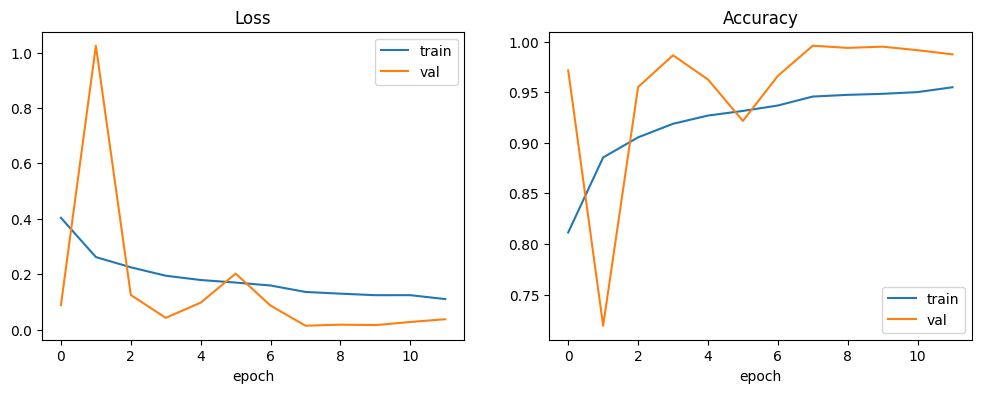

In [13]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(history['train_loss'], label='train')
ax[0].plot(history['val_loss'], label='val')
ax[0].set_title('Loss')
ax[0].set_xlabel('epoch')
ax[0].legend()

ax[1].plot(history['train_acc'], label='train')
ax[1].plot(history['val_acc'], label='val')
ax[1].set_title('Accuracy')
ax[1].set_xlabel('epoch')
ax[1].legend()
plt.show()

## 10. Evaluation

In [14]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve

ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt['model_state']); model.eval()
print(f"Loaded best (epoch {ckpt['epoch']}, val acc {ckpt['val_acc']:.4f})")

@torch.no_grad()
def predict_paths(paths, batch=64):
    probs, buf = [], []
    for i, p in enumerate(paths):
        try: 
            mel = preprocess(p)
        except Exception: 
            mel = np.zeros((N_MELS,188), dtype=np.float32)
        buf.append(mel)
        if len(buf)==batch or i==len(paths)-1:
            x = torch.from_numpy(np.stack(buf)).unsqueeze(1).to(device)
            probs.extend(torch.sigmoid(model(x)).cpu().numpy().tolist())
            buf=[]
    return np.array(probs)

def compute_eer(labels, scores):
    fpr, tpr, thr = roc_curve(labels, scores); fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fnr - fpr))
    return (fpr[idx]+fnr[idx])/2*100, thr[idx]

def full_report(name, labels, probs, threshold=0.5):
    labels = np.array(labels); preds = (probs > threshold).astype(int)
    acc = accuracy_score(labels, preds)*100; f1 = f1_score(labels, preds)*100
    eer, et = compute_eer(labels, probs); cm = confusion_matrix(labels, preds)
    ra = cm[0,0]/cm[0].sum()*100; fa = cm[1,1]/cm[1].sum()*100
    print(f'\n{name} (t={threshold:.2f})')
    print(f'Accuracy {acc:.2f}% | F1 {f1:.2f}% | EER {eer:.2f}% (t={et:.3f})')
    print(f'Per-class -> real {ra:.2f}% | fake {fa:.2f}%')
    print(f'CM [rows=true real/fake]:\n{cm}')
    return {'acc':acc,'f1':f1,'eer':eer,'real_acc':ra,'fake_acc':fa}

Loaded best (epoch 8, val acc 0.9958)


In [15]:
for_probs = predict_paths(test_paths)
asv_probs = predict_paths(asv_eval_p)
full_report('FoR TEST (in-distribution)', test_labels, for_probs, 0.5)
full_report('ASVspoof eval', asv_eval_l, asv_probs, 0.5)


FoR TEST (in-distribution) (t=0.50)
Accuracy 97.17% | F1 97.18% | EER 1.83% (t=0.175)
Per-class -> real 99.29% | fake 95.15%
CM [rows=true real/fake]:
[[2248   16]
 [ 115 2255]]

ASVspoof eval (t=0.50)
Accuracy 72.27% | F1 79.37% | EER 18.88% (t=0.229)
Per-class -> real 94.67% | fake 66.67%
CM [rows=true real/fake]:
[[284  16]
 [400 800]]


{'acc': 72.26666666666667,
 'f1': 79.36507936507937,
 'eer': np.float64(18.875),
 'real_acc': np.float64(94.66666666666667),
 'fake_acc': np.float64(66.66666666666666)}

## 11. Threshold calibration + export deploy bundle

In [16]:
import numpy as np
all_probs = np.concatenate([for_probs, asv_probs])
all_labels = np.array(list(test_labels) + list(asv_eval_l))
best_t, best_bal = 0.5, 0
for t in np.linspace(0.05, 0.6, 23):
    preds = (all_probs > t).astype(int)
    cm = confusion_matrix(all_labels, preds)
    bal = (cm[0,0]/cm[0].sum() + cm[1,1]/cm[1].sum())/2
    if bal > best_bal: 
        best_bal, best_t = bal, t
DEPLOY_THRESHOLD = float(best_t)
print(f'Deployment threshold: {DEPLOY_THRESHOLD:.3f} (balanced acc {best_bal:.3f})')

Deployment threshold: 0.175 (balanced acc 0.948)


In [17]:
# Export model + config for the app.
torch.save({
    'model_state': model.state_dict(),
    'arch': 'DeepfakeCNN_1ch',
    'config': {'SR':SR,'DURATION':DURATION,'N_SAMPLES':N_SAMPLES,'N_MELS':N_MELS,
               'N_FFT':N_FFT,'HOP_LENGTH':HOP_LENGTH,'TARGET_RMS':TARGET_RMS,
               'threshold':DEPLOY_THRESHOLD}
}, os.path.join(WORK_DIR, 'deploy_model.pt'))
print('Exported /kaggle/working/deploy_model.pt')

Exported /kaggle/working/deploy_model.pt
